In [1]:
!pip install yfinance


In [2]:
!pip install --upgrade yfinance


In [2]:
import os
os.environ["YF_USE_CURL"] = "0"

Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf
import seaborn as sns
from datetime import date
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import load_model
from tensorflow.keras import Input
from sklearn.metrics import r2_score


Define start day to fetch the dataset from the yahoo finance library


In [2]:
START="2015-01-01"
TODAY=date.today().strftime("%Y-%m-%d")
#Define a function to load the dataset
def load_data(ticker):
    data = yf.download(ticker,START,TODAY,auto_adjust=False)
    data.reset_index(inplace=True)
    return data

Load the Data

In [3]:
data=load_data('GOOGL')
df=data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
0,2015-01-02,26.260458,26.477501,26.790001,26.393999,26.629999,26480000
1,2015-01-05,25.760092,25.973000,26.399500,25.887501,26.357500,41182000
2,2015-01-06,25.124348,25.332001,26.060499,25.277500,26.025000,54456000
3,2015-01-07,25.050457,25.257500,25.574499,25.182501,25.547501,46918000
4,2015-01-08,25.137741,25.345501,25.375000,24.750999,25.075500,73054000


In [4]:
df.to_csv("Google_Stock_Price.csv", index=False)


In [5]:
#Shape of the dataset
df.shape

(2839, 7)

In [6]:
#Column names
df.columns

MultiIndex([(     'Date',      ''),
            ('Adj Close', 'GOOGL'),
            (    'Close', 'GOOGL'),
            (     'High', 'GOOGL'),
            (      'Low', 'GOOGL'),
            (     'Open', 'GOOGL'),
            (   'Volume', 'GOOGL')],
           names=['Price', 'Ticker'])

In [7]:
#Data types and null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2839 entries, 0 to 2838
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   (Date, )            2839 non-null   datetime64[ns]
 1   (Adj Close, GOOGL)  2839 non-null   float64       
 2   (Close, GOOGL)      2839 non-null   float64       
 3   (High, GOOGL)       2839 non-null   float64       
 4   (Low, GOOGL)        2839 non-null   float64       
 5   (Open, GOOGL)       2839 non-null   float64       
 6   (Volume, GOOGL)     2839 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 155.4 KB
None


In [8]:
#Summary statistics
print(df.describe())

Price                            Date    Adj Close        Close         High  \
Ticker                                       GOOGL        GOOGL        GOOGL   
count                            2839  2839.000000  2839.000000  2839.000000   
mean    2020-08-22 15:04:52.920042496    99.340417    99.972056   101.028409   
min               2015-01-02 00:00:00    24.649277    24.853001    25.014000   
25%               2017-10-25 12:00:00    49.902308    50.314751    50.733000   
50%               2020-08-21 00:00:00    75.210876    75.832497    76.494003   
75%               2023-06-18 00:00:00   135.870544   136.993500   138.212753   
max               2026-04-17 00:00:00   343.448242   343.690002   349.000000   
std                               NaN    66.737450    66.848928    67.618370   

Price           Low         Open        Volume  
Ticker        GOOGL        GOOGL         GOOGL  
count   2839.000000  2839.000000  2.839000e+03  
mean      98.835594    99.914731  3.520942e+07  
min

In [9]:
#Missing values per column
print(df.isnull().sum())

Price      Ticker
Date                 0
Adj Close  GOOGL     0
Close      GOOGL     0
High       GOOGL     0
Low        GOOGL     0
Open       GOOGL     0
Volume     GOOGL     0
dtype: int64


Visualize Stock Prices Over Time

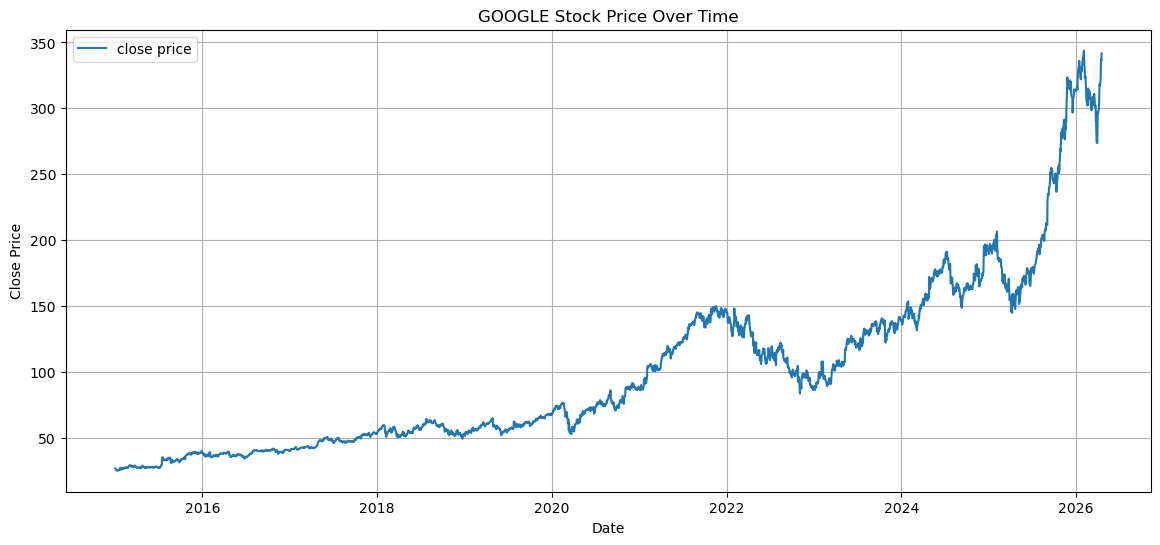

In [10]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df.Close,label='close price')
plt.title('GOOGLE Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
0,2015-01-02,26.260458,26.477501,26.790001,26.393999,26.629999,26480000
1,2015-01-05,25.760092,25.973000,26.399500,25.887501,26.357500,41182000
2,2015-01-06,25.124348,25.332001,26.060499,25.277500,26.025000,54456000
3,2015-01-07,25.050457,25.257500,25.574499,25.182501,25.547501,46918000
4,2015-01-08,25.137741,25.345501,25.375000,24.750999,25.075500,73054000
...,...,...,...,...,...,...,...
2834,2026-04-13,321.309998,321.309998,321.630005,315.470001,317.140015,18866400
2835,2026-04-14,332.910004,332.910004,333.290009,323.750000,324.790009,27721400
2836,2026-04-15,337.119995,337.119995,337.480011,330.899994,332.890015,24918800


Distribution of Stock Prices

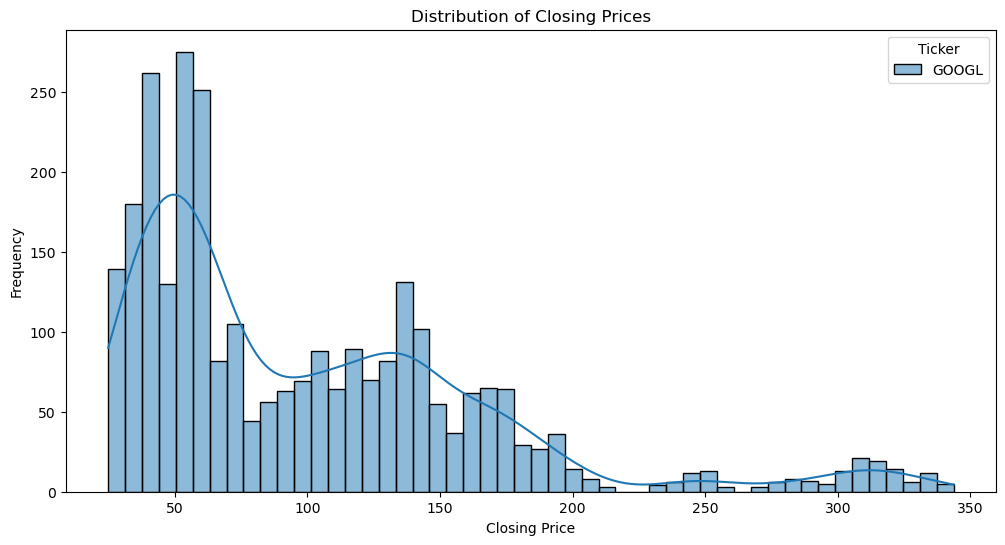

In [12]:
plt.figure(figsize=(12,6))
sns.histplot(df['Close'],kde=True,bins=50)
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()


Correlation Between Features

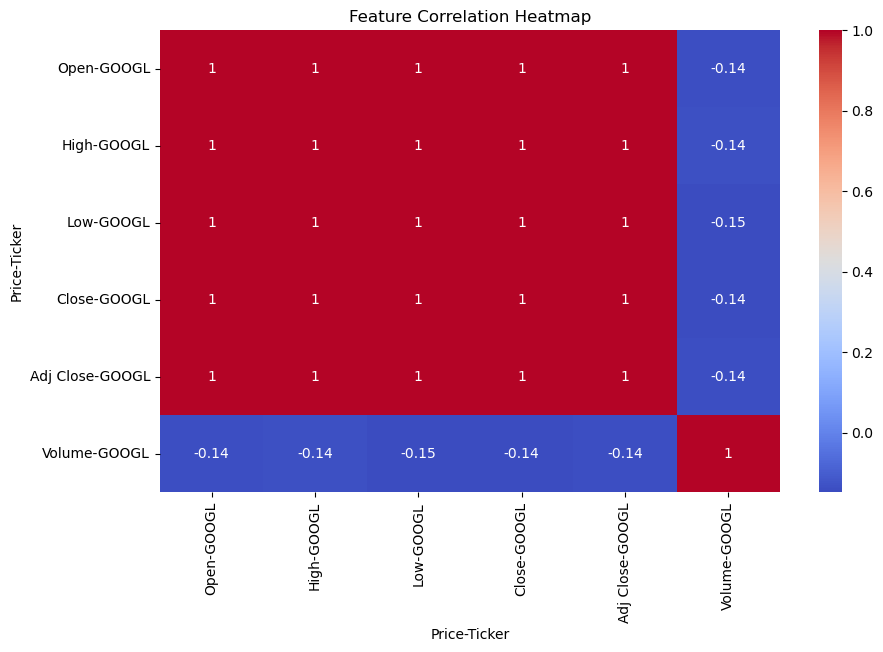

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close','Adj Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


Moving Averages

In [14]:
ma100=df.Close.rolling(100).mean()
ma100

Ticker,GOOGL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2834,312.482999
2835,312.961899
2836,313.490299
2837,313.922399


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

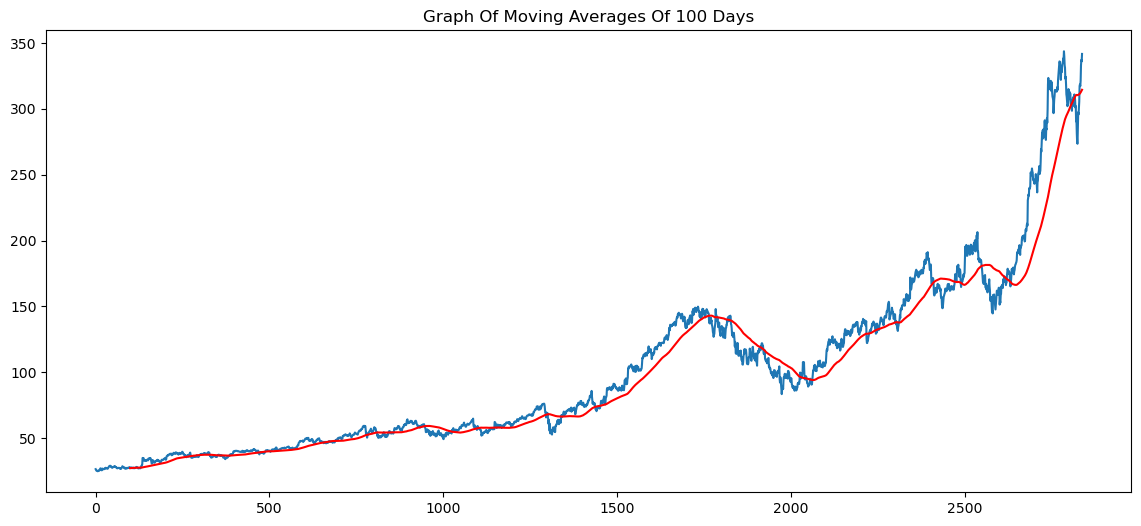

In [15]:
plt.figure(figsize=(14,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.title('Graph Of Moving Averages Of 100 Days')

In [16]:
ma200=df.Close.rolling(200).mean()
ma200

Ticker,GOOGL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2834,269.30195
2835,270.09880
2836,270.89175
2837,271.69070


Text(0.5, 1.0, 'Graph Of Moving Averages Of 200 Days')

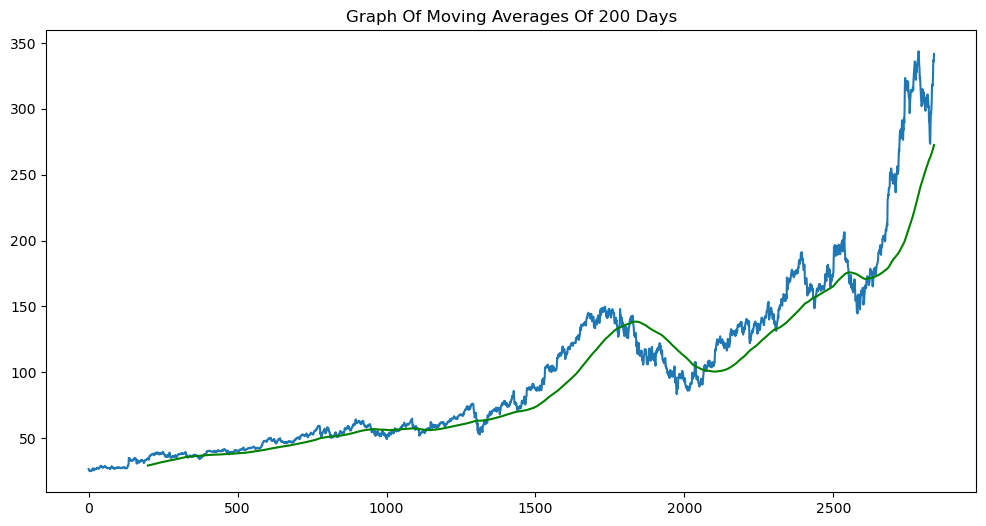

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma200,'g')
plt.title('Graph Of Moving Averages Of 200 Days')

Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

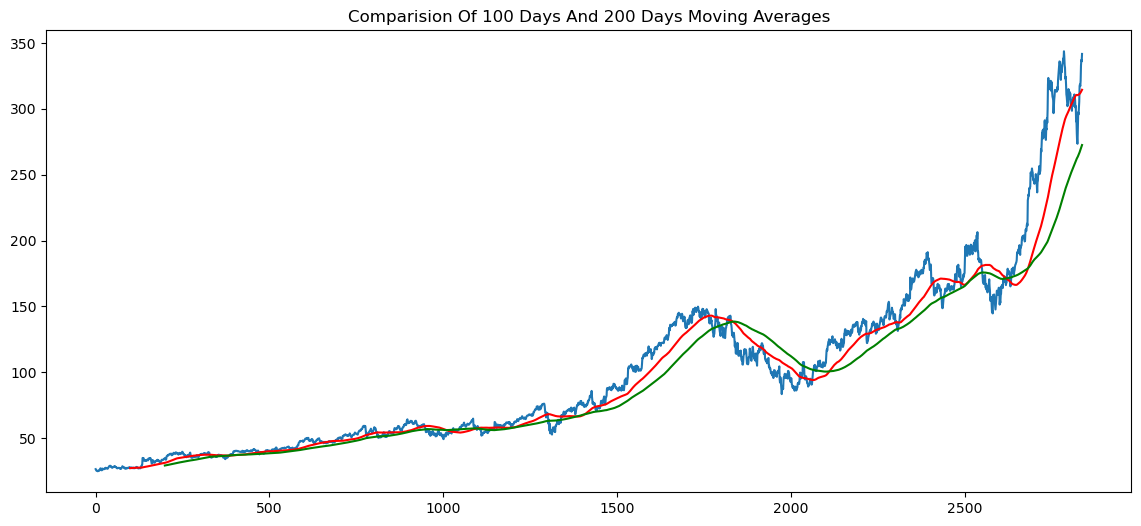

In [18]:
plt.figure(figsize=(14,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

 Daily Returns

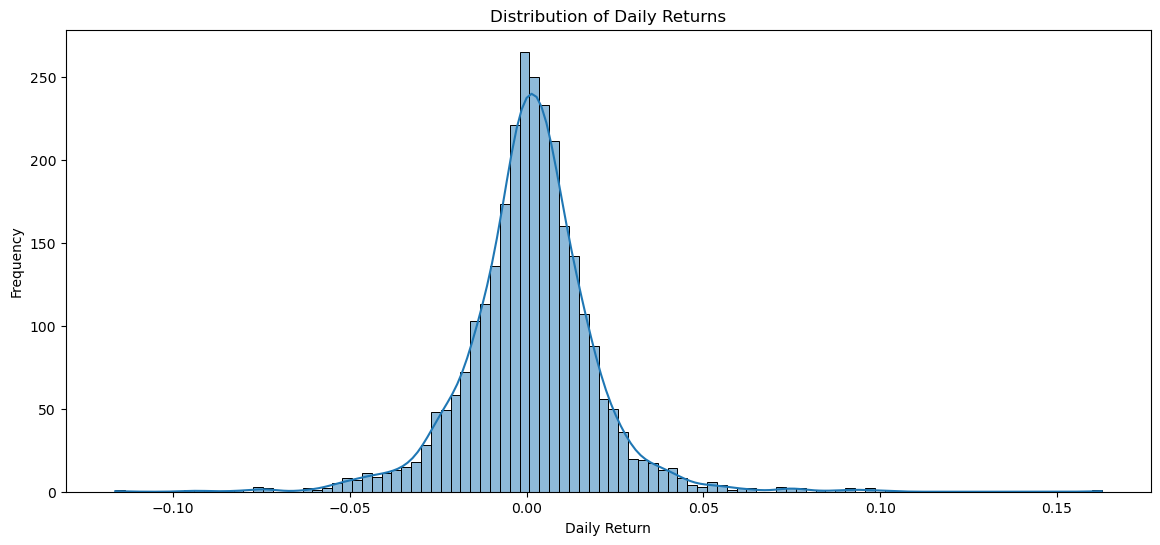

In [19]:
df['Daily Return']=df['Close'].pct_change()
plt.figure(figsize=(14,6))
sns.histplot(df['Daily Return'].dropna(),bins=100,kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


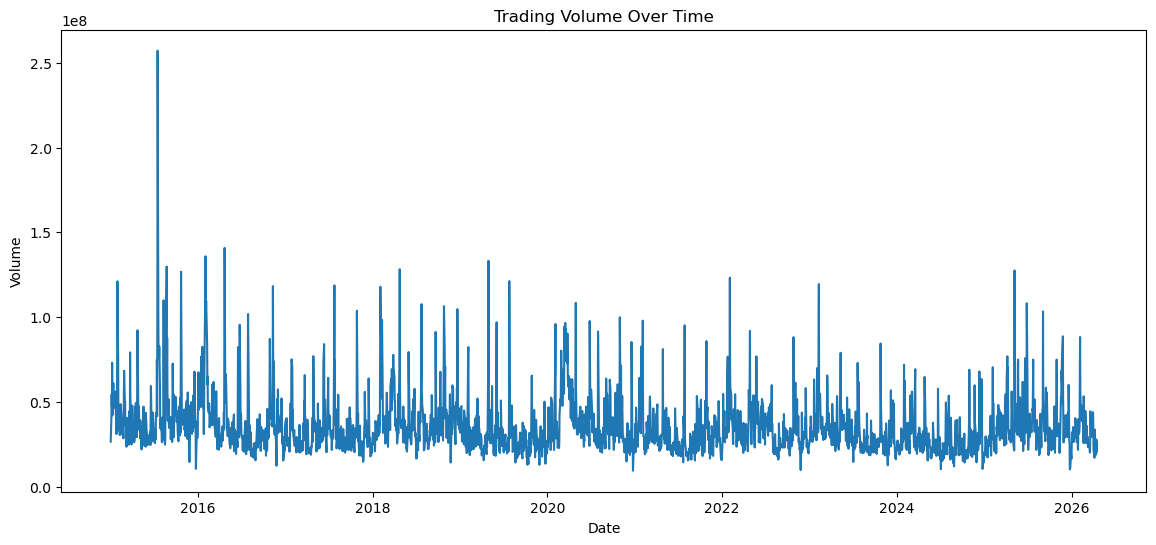

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df['Volume'],label='Volume')
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()


In [21]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Daily Return
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
0,2015-01-02,26.260458,26.477501,26.790001,26.393999,26.629999,26480000,NaN
1,2015-01-05,25.760092,25.973000,26.399500,25.887501,26.357500,41182000,-0.019054
2,2015-01-06,25.124348,25.332001,26.060499,25.277500,26.025000,54456000,-0.024679
3,2015-01-07,25.050457,25.257500,25.574499,25.182501,25.547501,46918000,-0.002941
4,2015-01-08,25.137741,25.345501,25.375000,24.750999,25.075500,73054000,0.003484
...,...,...,...,...,...,...,...,...
2834,2026-04-13,321.309998,321.309998,321.630005,315.470001,317.140015,18866400,0.012829
2835,2026-04-14,332.910004,332.910004,333.290009,323.750000,324.790009,27721400,0.036102
2836,2026-04-15,337.119995,337.119995,337.480011,330.899994,332.890015,24918800,0.012646


In [22]:
#drop columns
df=df.drop(['Adj Close','Daily Return'],axis=1)
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_7328\1774851537.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['Adj Close','Daily Return'],axis=1)


Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
0,2015-01-02,26.477501,26.790001,26.393999,26.629999,26480000
1,2015-01-05,25.973000,26.399500,25.887501,26.357500,41182000
2,2015-01-06,25.332001,26.060499,25.277500,26.025000,54456000
3,2015-01-07,25.257500,25.574499,25.182501,25.547501,46918000
4,2015-01-08,25.345501,25.375000,24.750999,25.075500,73054000


In [23]:
#Use only the Close price for prediction
data=df[['Close']]

In [24]:
#Normalize the data
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)

In [25]:
#Create sequences
sequence_length=60
X=[]
y=[]
for i in range(sequence_length,len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i,0])
    y.append(scaled_data[i,0])
X,y=np.array(X),np.array(y)
X=np.reshape(X,(X.shape[0],X.shape[1],1))  #Reshape for LSTM

In [26]:
#Train-Test Split
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [27]:
#Build the LSTM model
m=Sequential([
    Input(shape=(X.shape[1],1)),  
    LSTM(units=64,return_sequences=True),
    Dropout(0.2),
    LSTM(units=32),
    Dense(1)   
])
m.compile(optimizer='adam',loss='mean_squared_error')

In [28]:
#Train the model
m.fit(X_train,y_train,epochs=40,batch_size=32)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0058
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.7488e-04
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 1.4072e-04
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 1.3210e-04
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 1.3483e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 1.2023e-04
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.2741e-04
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 1.3168e-04
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 1.3006e-04
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 1.2178e-04
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.1485e-04
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.1417e-04
Epoch 13/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.1845e-04
Epoch 14/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 9.7430e-05
Epoch 15/40
70/70 

In [29]:
#Predict and inverse scale
predicted_prices=m.predict(X_test)
predicted_prices=scaler.inverse_transform(predicted_prices.reshape(-1,1))
actual_prices=scaler.inverse_transform(y_test.reshape(-1,1))
y_pred=m.predict(X_test)
y_pred

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[0.3901747 ],
       [0.3923622 ],
       [0.385893  ],
       [0.3771294 ],
       [0.3695524 ],
       [0.36490864],
       [0.3630824 ],
       [0.36413825],
       [0.36685175],
       [0.37190723],
       [0.3762827 ],
       [0.3780265 ],
       [0.37854576],
       [0.3762732 ],
       [0.3716432 ],
       [0.36706668],
       [0.364254  ],
       [0.36385497],
       [0.36475307],
       [0.36234546],
       [0.35966694],
       [0.3558037 ],
       [0.35340607],
       [0.35141328],
       [0.34782335],
       [0.34380758],
       [0.33961028],
       [0.3379566 ],
       [0.33853394],
       [0.34155408],
       [0.34574854],
       [0.35049736],
       [0.3565304 ],
       [0.36072928],
       [0.3670421 ],
       [0.37253362],
       [0.37747502],
       [0.3802719 ],
       [0.3832534 ],
       [0.38511276],
       [0.38634443],
       [0.3870617 ],
       [0.38738176],
       [0.39026022],
       [0.39323342],
       [0.39597726],
       [0.39534238],
       [0.394

Evaluation Metrics

In [30]:
#mse
mse=mean_squared_error(actual_prices,predicted_prices)
print(f"MSE:{mse}")
#mae
mae=mean_absolute_error(actual_prices,predicted_prices)
print(f"MAE:{mae}")
#rmse
rmse=np.sqrt(mse)
print(f"RMSE:{rmse}")
#r2 SCORE
r2 = r2_score(y_test,y_pred)  
print(f"r2 Score:{r2}")


MSE:113.90066268389106
MAE:7.904362410950146
RMSE:10.672425342155881
r2 Score:0.9680108767158496


In [31]:
#Get the dates corresponding to the test set
test_dates=df['Date'].iloc[sequence_length+split:].reset_index(drop=True)

In [32]:
#Ensure actual and predicted prices have same shape
actual_prices=actual_prices[:len(test_dates)]
predicted_prices=predicted_prices[:len(test_dates)]

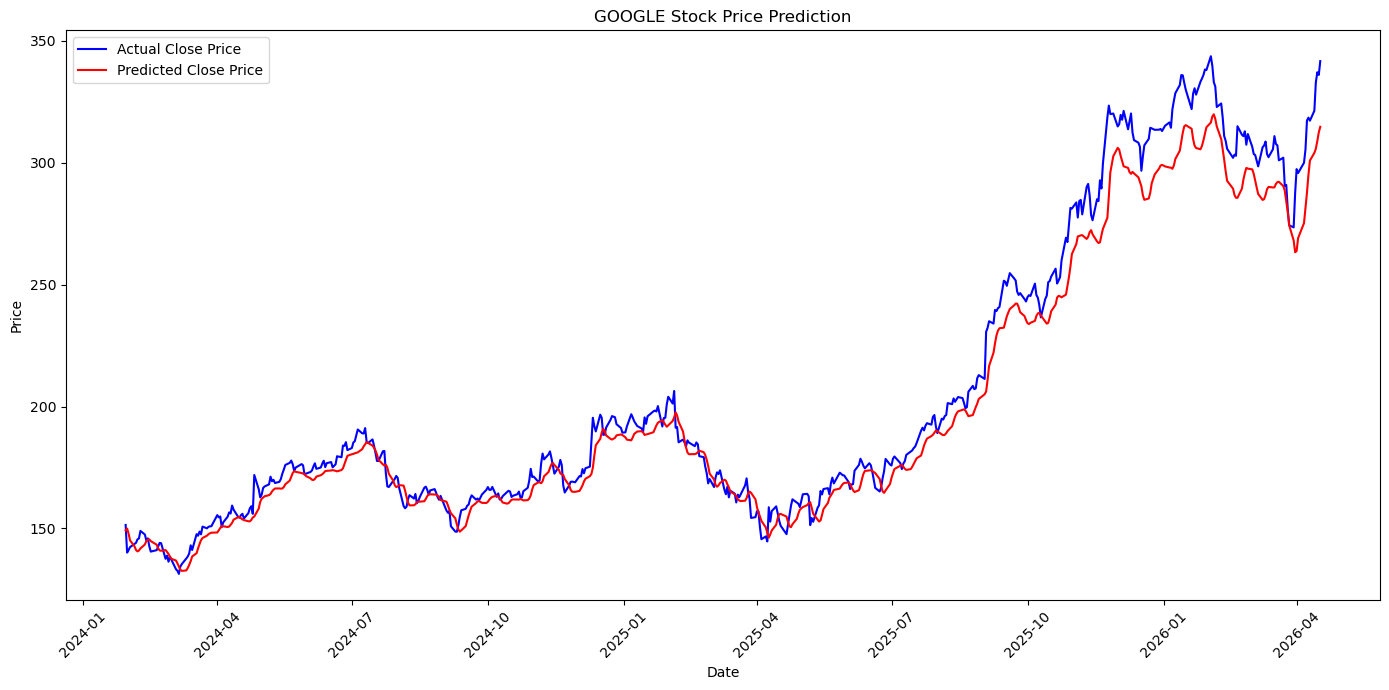

In [33]:
# Plot with Date Index
plt.figure(figsize=(14,7))
plt.plot(test_dates,actual_prices,color='blue',label='Actual Close Price')
plt.plot(test_dates,predicted_prices,color='red',label='Predicted Close Price')
plt.title('GOOGLE Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
# Results DataFrame
results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': actual_prices.flatten(),
    'Predicted': predicted_prices.flatten(),
    })

In [35]:
results_df

,Date,Actual,Predicted
0,2024-01-30,151.460007,149.255127
1,2024-01-31,140.100006,149.952591
2,2024-02-01,141.160004,147.889969
3,2024-02-02,142.380005,145.095810
4,2024-02-05,143.679993,142.679977
...,...,...,...
551,2026-04-13,321.309998,304.032562
552,2026-04-14,332.910004,305.756042
553,2026-04-15,337.119995,308.898560
554,2026-04-16,336.019989,312.467377


In [36]:
#Difference Between Actual and Predicted values
results_df['difference']=results_df['Actual']-results_df['Predicted']
results_df

,Date,Actual,Predicted,difference
0,2024-01-30,151.460007,149.255127,2.204880
1,2024-01-31,140.100006,149.952591,-9.852585
2,2024-02-01,141.160004,147.889969,-6.729965
3,2024-02-02,142.380005,145.095810,-2.715805
4,2024-02-05,143.679993,142.679977,1.000015
...,...,...,...,...
551,2026-04-13,321.309998,304.032562,17.277435
552,2026-04-14,332.910004,305.756042,27.153961
553,2026-04-15,337.119995,308.898560,28.221436
554,2026-04-16,336.019989,312.467377,23.552612


In [37]:
#Save the Trained model
m.save("m.h5") 

In [1]:
df='divyakanwar'

In [3]:
df[::-1]

'rawnakayvid'

In [4]:
d="eeeeggggghhhhh"

In [8]:
d.count('e')

4